# Лабораторная работа №3 — Статистика случайных процессов

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from scipy.stats import norm, gamma, ncx2

SEED = 42
np.random.seed(SEED)

plt.rcParams.update({
    "figure.figsize": (12, 5),
    "axes.grid": True,
    "font.size": 12,
})

## Задача 1. Сравнительный анализ численных схем (BSM)

In [2]:
class BSMNumericalSchemes:
    """Геометрическое броуновское движение (BSM) и его численные решения."""
    def __init__(self, mu=1.0, sigma=0.5, X0=1.0, T=1.0):
        self.mu = mu
        self.sigma = sigma
        self.X0 = X0
        self.T = T
        
    def exact_solution(self, t, W):
        return self.X0 * np.exp((self.mu - 0.5 * self.sigma**2) * t + self.sigma * W)
    
    def simulate(self, N):
        dt = self.T / N
        t = np.linspace(0, self.T, N + 1)
        dW = np.random.normal(0, np.sqrt(dt), N)
        W = np.concatenate(([0], np.cumsum(dW)))
        
        # Для KPS генерация dZ
        xi = np.random.normal(0, 1, N)
        dU = 0.5 * dt * dW + (np.sqrt(3) / 6) * (dt**1.5) * xi
        
        X_exact = self.exact_solution(t, W)
        
        X_EM = np.zeros(N + 1); X_EM[0] = self.X0
        X_M1 = np.zeros(N + 1); X_M1[0] = self.X0
        X_M2 = np.zeros(N + 1); X_M2[0] = self.X0
        X_PC = np.zeros(N + 1); X_PC[0] = self.X0
        X_KPS = np.zeros(N + 1); X_KPS[0] = self.X0
        
        alpha, eta = 0.5, 0.5
        
        for i in range(N):
            # Euler-Maruyama
            X_EM[i+1] = X_EM[i] + self.mu * X_EM[i] * dt + self.sigma * X_EM[i] * dW[i]
            
            # Milstein 1
            X_M1[i+1] = X_M1[i] + self.mu * X_M1[i] * dt + self.sigma * X_M1[i] * dW[i] + \
                        0.5 * self.sigma**2 * X_M1[i] * (dW[i]**2 - dt)
                        
            # Milstein 2
            # Для BSM: Y + (mu Y - 0.5 sigma^2 Y) dt + sigma Y dW + 0.5 sigma^2 Y dW^2 + mu sigma Y dt dW + 0.5 mu^2 Y dt^2
            X_M2[i+1] = X_M2[i] + self.mu * X_M2[i] * dt + self.sigma * X_M2[i] * dW[i] + \
                        0.5 * self.sigma**2 * X_M2[i] * (dW[i]**2 - dt) + \
                        self.mu * self.sigma * X_M2[i] * dt * dW[i] + \
                        0.5 * self.mu**2 * X_M2[i] * dt**2
                        
            # Predictor-Corrector
            pred = X_PC[i] + self.mu * X_PC[i] * dt + self.sigma * X_PC[i] * dW[i]
            # tilde_b = b - eta * sigma * sigma_x = (mu - eta * sigma^2) X
            tilde_b_pred = (self.mu - eta * self.sigma**2) * pred
            tilde_b_curr = (self.mu - eta * self.sigma**2) * X_PC[i]
            
            X_PC[i+1] = X_PC[i] + (alpha * tilde_b_pred + (1 - alpha) * tilde_b_curr) * dt + \
                        (eta * self.sigma * pred + (1 - eta) * self.sigma * X_PC[i]) * dW[i]
                        
            # KPS
            X_KPS[i+1] = X_KPS[i] + self.mu * X_KPS[i] * dt + self.sigma * X_KPS[i] * dW[i] + \
                         0.5 * self.sigma**2 * X_KPS[i] * (dW[i]**2 - dt) + \
                         self.mu * self.sigma * X_KPS[i] * dU[i] + \
                         0.5 * self.mu**2 * X_KPS[i] * dt**2 + \
                         self.mu * self.sigma * X_KPS[i] * (dW[i]*dt - dU[i]) + \
                         0.5 * self.sigma**3 * X_KPS[i] * (dW[i]**2 / 3.0 - dt) * dW[i]
                         
        return {
            "Exact": X_exact,
            "Euler-Maruyama": X_EM,
            "Milstein 1": X_M1,
            "Milstein 2": X_M2,
            "Predictor-Corrector": X_PC,
            "KPS": X_KPS
        }

np.random.seed(SEED)
bsm_tester = BSMNumericalSchemes(mu=1.0, sigma=0.5, X0=1.0, T=1.0)
res = bsm_tester.simulate(N=1024)

errors = {}
for name, traj in res.items():
    if name != "Exact":
        errors[name] = np.max(np.abs(traj - res["Exact"]))
        
df_errors = pd.DataFrame(list(errors.items()), columns=["Method", "Max Absolute Error"])
display(df_errors.sort_values("Max Absolute Error"))


,Method,Max Absolute Error
4,KPS,0.000020
2,Milstein 2,0.000242
3,Predictor-Corrector,0.000530
1,Milstein 1,0.002978
0,Euler-Maruyama,0.019567


## Задача 2. Исследование скорости сходимости

In [5]:
# Прогоняем для разных N. Для чистоты эксперимента нужно строить путь из одного и того же винеровского процесса.
# Но так как сетки разные, мы сгенерируем самый подробный dW и будем его агрегировать.

N_max = 32768
N_list = [2**i for i in range(1, 16)] # 2, 4, 8 ... 32768
dt_max = 1.0 / N_max
t_max = np.linspace(0, 1.0, N_max + 1)
np.random.seed(SEED)
dW_max = np.random.normal(0, np.sqrt(dt_max), N_max)
W_max = np.concatenate(([0], np.cumsum(dW_max)))
X_exact_max = bsm_tester.exact_solution(t_max, W_max)

errors_em = []
errors_m1 = []
errors_m2 = []

for N in N_list:
    step = N_max // N
    dt = 1.0 / N
    dW = dW_max.reshape(N, step).sum(axis=1)
 
    X_EM = np.zeros(N + 1); X_EM[0] = bsm_tester.X0
    X_M1 = np.zeros(N + 1); X_M1[0] = bsm_tester.X0
    X_M2 = np.zeros(N + 1); X_M2[0] = bsm_tester.X0
    
    for i in range(N):
        X_EM[i+1] = X_EM[i] + bsm_tester.mu * X_EM[i] * dt + bsm_tester.sigma * X_EM[i] * dW[i]
        
        X_M1[i+1] = X_M1[i] + bsm_tester.mu * X_M1[i] * dt + bsm_tester.sigma * X_M1[i] * dW[i] + \
                    0.5 * bsm_tester.sigma**2 * X_M1[i] * (dW[i]**2 - dt)
                    
        X_M2[i+1] = X_M2[i] + bsm_tester.mu * X_M2[i] * dt + bsm_tester.sigma * X_M2[i] * dW[i] + \
                    0.5 * bsm_tester.sigma**2 * X_M2[i] * (dW[i]**2 - dt) + \
                    bsm_tester.mu * bsm_tester.sigma * X_M2[i] * dt * dW[i] + \
                    0.5 * bsm_tester.mu**2 * X_M2[i] * dt**2
                    
    X_true_nodes = X_exact_max[::step]
    errors_em.append(np.max(np.abs(X_EM - X_true_nodes)))
    errors_m1.append(np.max(np.abs(X_M1 - X_true_nodes)))
    errors_m2.append(np.max(np.abs(X_M2 - X_true_nodes)))

errors_em = np.array(errors_em)
errors_m1 = np.array(errors_m1)
errors_m2 = np.array(errors_m2)


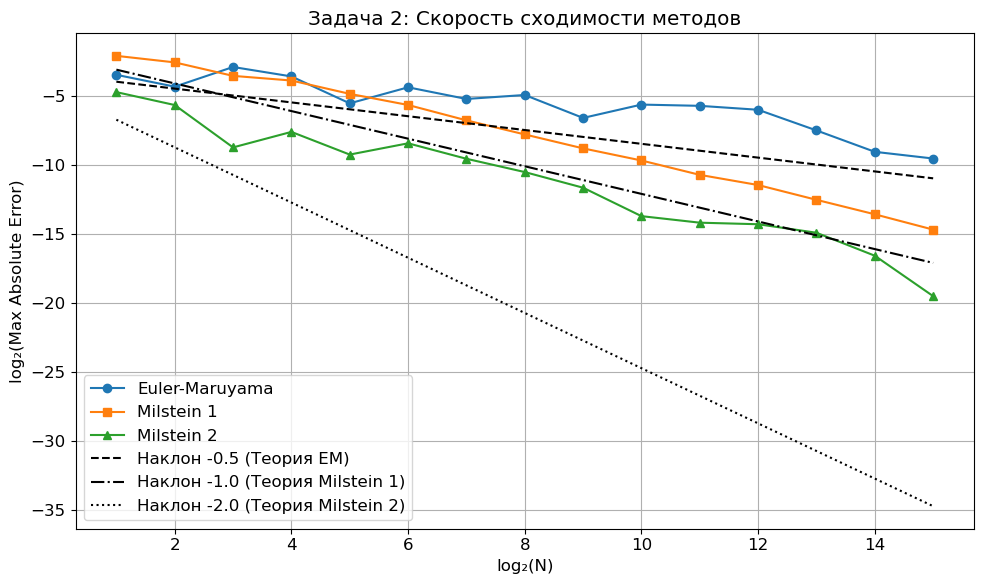

Фактический наклон EM: 0.39
Фактический наклон Milstein 1: 0.92
Фактический наклон Milstein 2: 0.91


In [6]:
plt.figure(figsize=(10, 6))
plt.plot(np.log2(N_list), np.log2(errors_em), 'o-', label='Euler-Maruyama')
plt.plot(np.log2(N_list), np.log2(errors_m1), 's-', label='Milstein 1')
plt.plot(np.log2(N_list), np.log2(errors_m2), '^-', label='Milstein 2')

# Референсные линии (наклоны -0.5, -1.0, -2.0)
x_ref = np.log2(N_list)
plt.plot(x_ref, -0.5 * x_ref + np.log2(errors_em[0]), 'k--', label='Наклон -0.5 (Теория EM)')
plt.plot(x_ref, -1.0 * x_ref + np.log2(errors_m1[0]), 'k-.', label='Наклон -1.0 (Теория Milstein 1)')
plt.plot(x_ref, -2.0 * x_ref + np.log2(errors_m2[0]), 'k:', label='Наклон -2.0 (Теория Milstein 2)')

plt.xlabel('log₂(N)')
plt.ylabel('log₂(Max Absolute Error)')
plt.title('Задача 2: Скорость сходимости методов')
plt.legend()
plt.tight_layout()
plt.show()

# Линейная регрессия для оценки фактического порядка
from scipy.stats import linregress
print(f"Фактический наклон EM: {-linregress(np.log2(N_list), np.log2(errors_em)).slope:.2f}")
print(f"Фактический наклон Milstein 1: {-linregress(np.log2(N_list), np.log2(errors_m1)).slope:.2f}")
print(f"Фактический наклон Milstein 2: {-linregress(np.log2(N_list), np.log2(errors_m2)).slope:.2f}")


## Задача 3. Оптимизация метода «прогноз-коррекция»

In [7]:
def pc_error(alpha, eta, N, M=20):
    """Средняя максимальная ошибка по M траекториям."""
    err_sum = 0
    dt = 1.0 / N
    t = np.linspace(0, 1.0, N + 1)
    
    for _ in range(M):
        dW = np.random.normal(0, np.sqrt(dt), N)
        W = np.concatenate(([0], np.cumsum(dW)))
        X_exact = bsm_tester.exact_solution(t, W)
        
        X_PC = np.zeros(N + 1); X_PC[0] = bsm_tester.X0
        for i in range(N):
            pred = X_PC[i] + bsm_tester.mu * X_PC[i] * dt + bsm_tester.sigma * X_PC[i] * dW[i]
            tilde_b_pred = (bsm_tester.mu - eta * bsm_tester.sigma**2) * pred
            tilde_b_curr = (bsm_tester.mu - eta * bsm_tester.sigma**2) * X_PC[i]
            
            X_PC[i+1] = X_PC[i] + (alpha * tilde_b_pred + (1 - alpha) * tilde_b_curr) * dt + \
                        (eta * bsm_tester.sigma * pred + (1 - eta) * bsm_tester.sigma * X_PC[i]) * dW[i]
        err_sum += np.max(np.abs(X_PC - X_exact))
    return err_sum / M

np.random.seed(SEED)
alphas = np.linspace(0, 1, 11)
etas = np.linspace(0, 1, 11)
A, E = np.meshgrid(alphas, etas)
Z = np.zeros_like(A)

for i in range(len(etas)):
    for j in range(len(alphas)):
        Z[i, j] = pc_error(alphas[j], etas[i], N=1024, M=10)


Оптимальные параметры: α = 0.60, η = 0.50, Ошибка = 0.000178


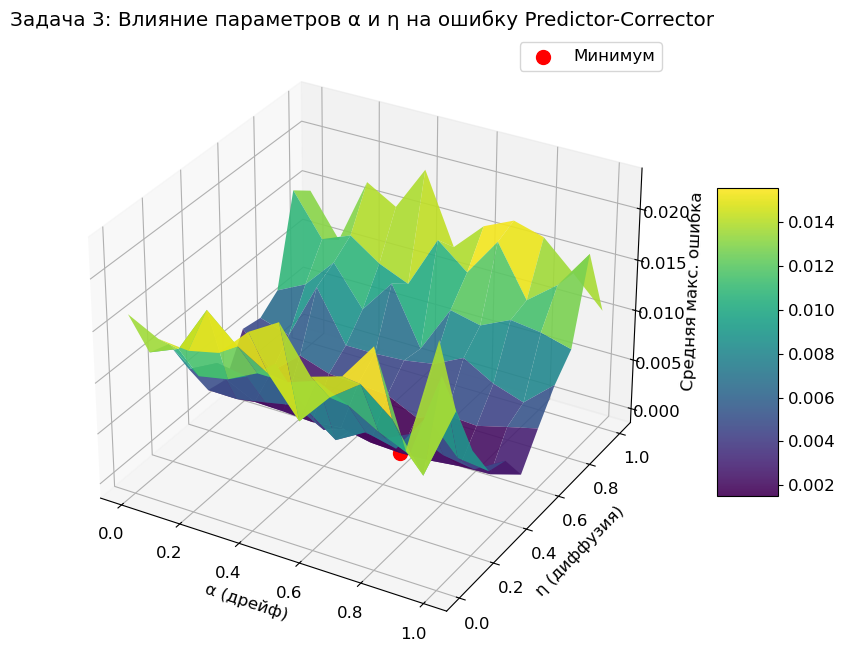

In [8]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(A, E, Z, cmap='viridis', edgecolor='none', alpha=0.9)
ax.set_xlabel('α (дрейф)')
ax.set_ylabel('η (диффузия)')
ax.set_zlabel('Средняя макс. ошибка')
ax.set_title('Задача 3: Влияние параметров α и η на ошибку Predictor-Corrector')
fig.colorbar(surf, shrink=0.5, aspect=5)

opt_idx = np.unravel_index(np.argmin(Z), Z.shape)
opt_alpha, opt_eta = A[opt_idx], E[opt_idx]
print(f"Оптимальные параметры: α = {opt_alpha:.2f}, η = {opt_eta:.2f}, Ошибка = {Z[opt_idx]:.6f}")

ax.scatter([opt_alpha], [opt_eta], [Z[opt_idx]], color='red', s=100, label='Минимум')
ax.legend()
plt.show()


## Задача 4. Моделирование экзотических процессов

In [9]:
class ExoticProcesses:
    """Генераторы экзотических процессов."""
    def __init__(self, T=1.0, Nt=1000, M=1000):
        self.T = T
        self.Nt = Nt
        self.M = M
        self.dt = T / Nt
        self.t = np.linspace(0, T, Nt + 1)
        
    def generate_paths(self, b_fn, sigma_fn, X0, bounds=None):
        X = np.zeros((self.Nt + 1, self.M))
        X[0] = X0
        
        for i in range(self.Nt):
            dW = np.random.normal(0, np.sqrt(self.dt), self.M)
            X[i+1] = X[i] + b_fn(X[i]) * self.dt + sigma_fn(X[i]) * dW
            if bounds:
                X[i+1] = np.clip(X[i+1], bounds[0], bounds[1])
        return X

exo = ExoticProcesses(T=1.0, Nt=1000, M=1000)
np.random.seed(SEED)

# 1. Pearson process
theta_p, mu_p, a_p, b_p, c_p = 1.0, 1.0, 0.1, 0.0, 0.1
b_pearson = lambda x: -theta_p * (x - mu_p)
sig_pearson = lambda x: np.sqrt(np.maximum(2 * theta_p * (a_p * x**2 + b_p * x + c_p), 0))
X_pearson = exo.generate_paths(b_pearson, sig_pearson, X0=1.0)

# 2. Jacobi diffusion (bounds in 0..1)
kappa_j, theta_j, sigma_j = 2.0, 0.5, 0.3
b_jacobi = lambda x: kappa_j * (theta_j - x)
sig_jacobi = lambda x: sigma_j * np.sqrt(np.clip(x * (1 - x), 0, None))
X_jacobi = exo.generate_paths(b_jacobi, sig_jacobi, X0=0.5, bounds=(1e-5, 1-1e-5))

# 3. Radial OU
theta_r = 1.0
b_radial = lambda x: (theta_r / np.maximum(x, 1e-4)) - x
sig_radial = lambda x: 1.0
X_radial = exo.generate_paths(b_radial, sig_radial, X0=0.5, bounds=(1e-4, np.inf))

# 4. Ahn and Gao
kappa_ag, theta_ag, sigma_ag = 1.0, 1.0, 0.5
b_ag = lambda x: kappa_ag * (theta_ag - x) * x
sig_ag = lambda x: sigma_ag * np.maximum(x, 0)**1.5
X_ag = exo.generate_paths(b_ag, sig_ag, X0=1.0, bounds=(1e-5, np.inf))

processes_data = {
    "Pearson Process": X_pearson,
    "Jacobi Diffusion": X_jacobi,
    "Radial OU": X_radial,
    "Ahn and Gao": X_ag
}


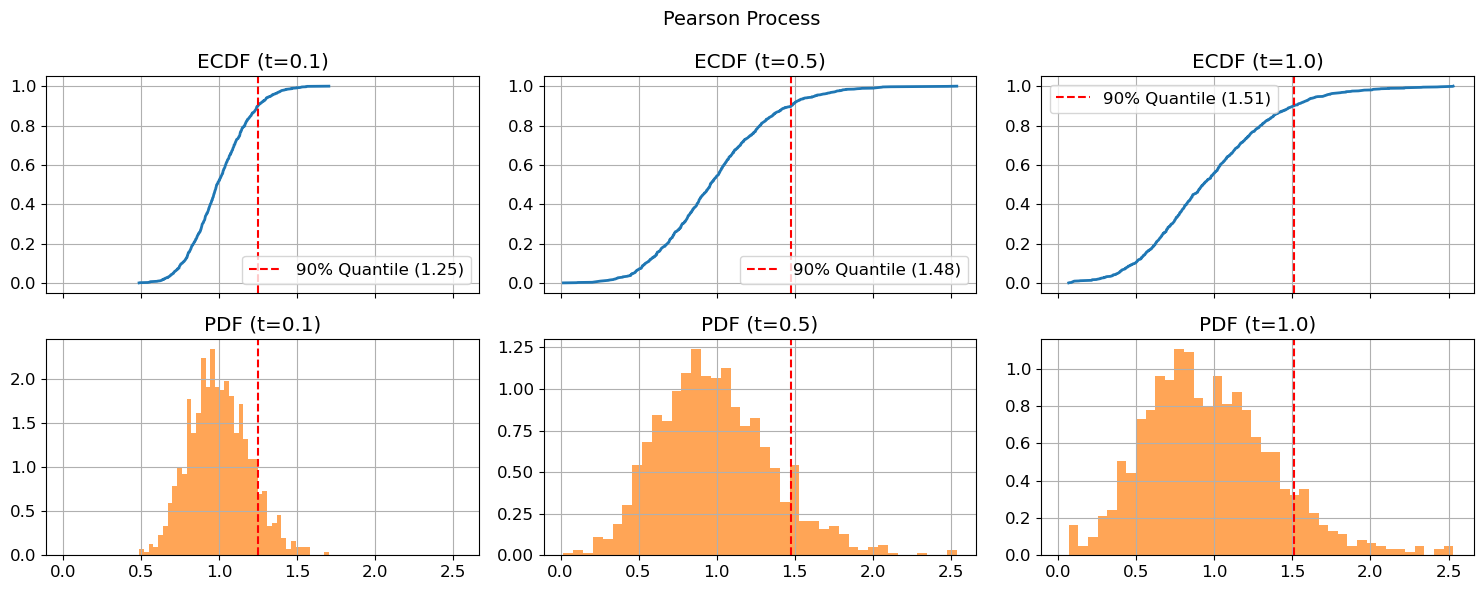

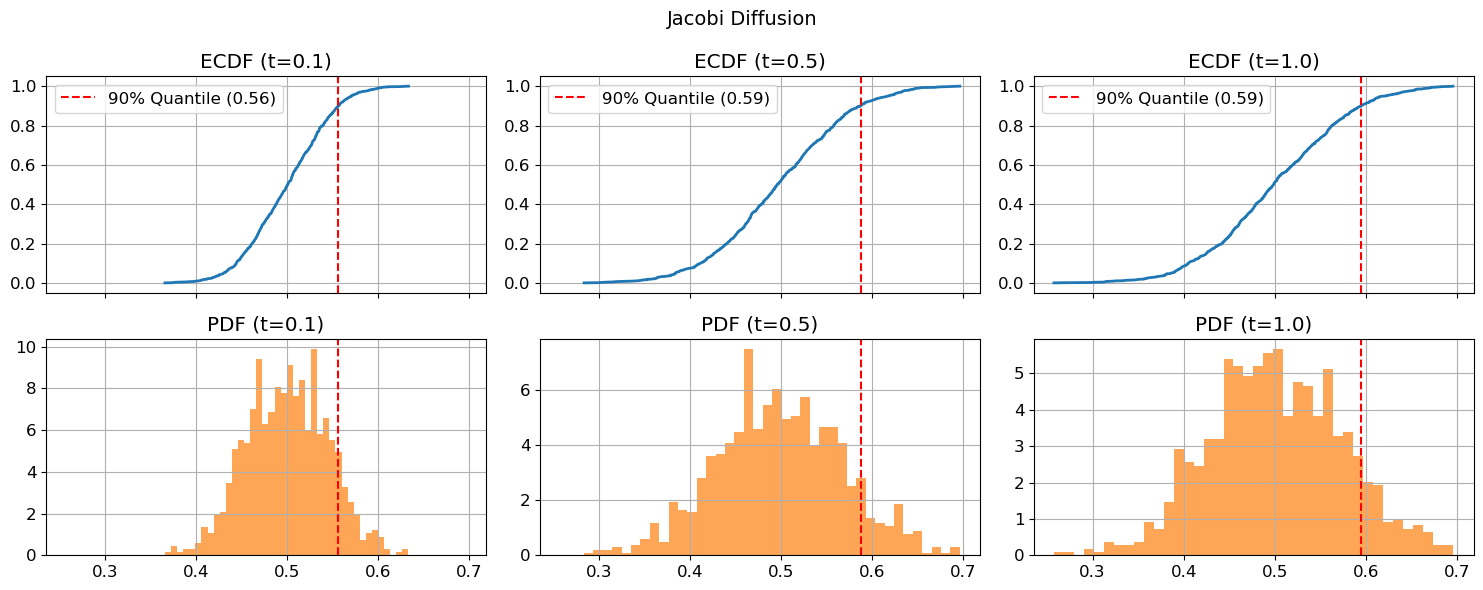

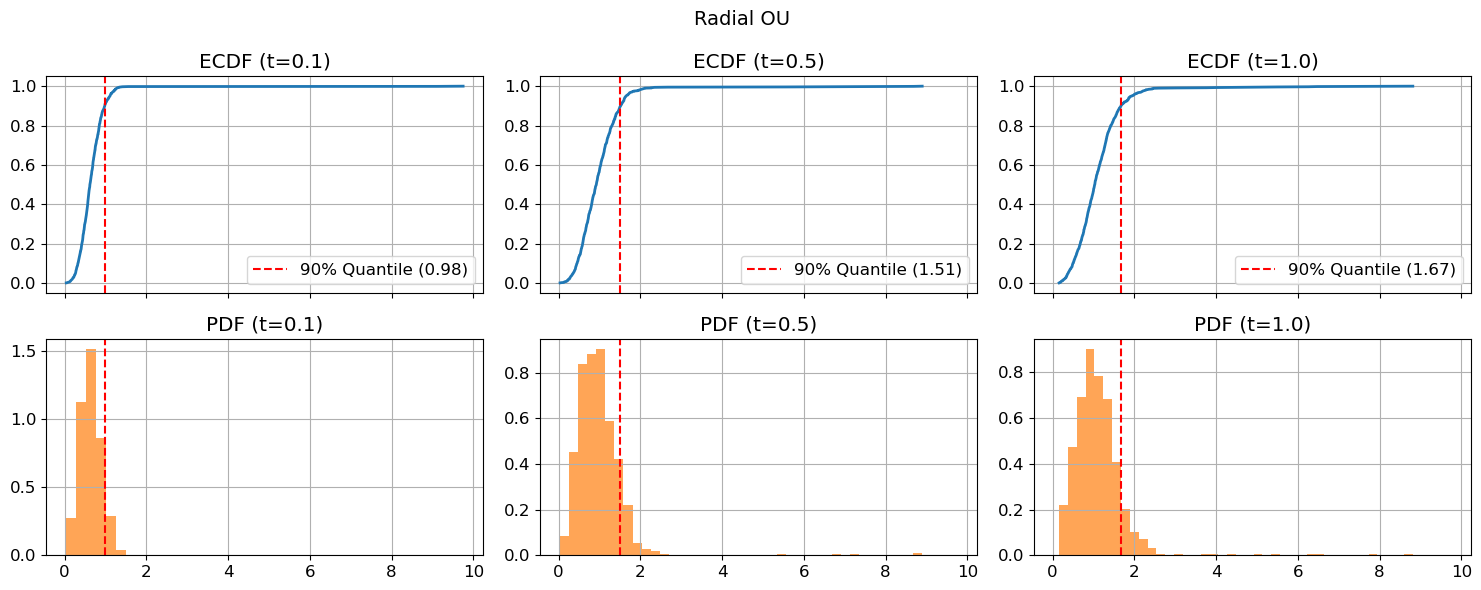

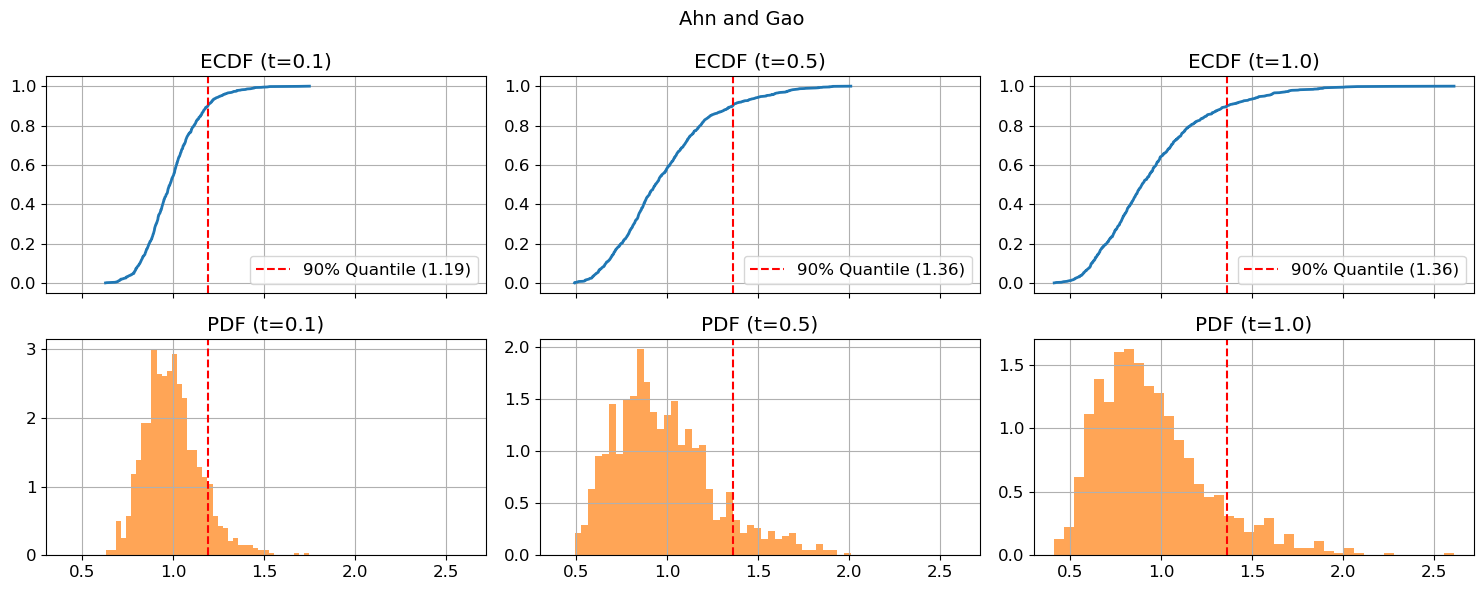

In [10]:
t_indices = [int(0.1 / exo.dt), int(0.5 / exo.dt), int(1.0 / exo.dt)]
t_labels = ["t=0.1", "t=0.5", "t=1.0"]

for name, X in processes_data.items():
    fig, axes = plt.subplots(2, 3, figsize=(15, 6), sharex=True)
    fig.suptitle(f"{name}", fontsize=14)
    
    for idx, (t_idx, t_lbl) in enumerate(zip(t_indices, t_labels)):
        data = X[t_idx]
        q90 = np.quantile(data, 0.90)
        
        # ECDF
        x_sort = np.sort(data)
        y_ecdf = np.arange(1, len(x_sort)+1) / len(x_sort)
        axes[0, idx].plot(x_sort, y_ecdf, lw=2, color='tab:blue')
        axes[0, idx].axvline(q90, color='red', ls='--', label=f'90% Quantile ({q90:.2f})')
        axes[0, idx].set_title(f"ECDF ({t_lbl})")
        axes[0, idx].legend()
        
        # PDF (Histogram)
        axes[1, idx].hist(data, bins=40, density=True, alpha=0.7, color='tab:orange')
        axes[1, idx].axvline(q90, color='red', ls='--')
        axes[1, idx].set_title(f"PDF ({t_lbl})")
        
    plt.tight_layout()
    plt.show()


## Задача 5. Условные и стационарные распределения OU и CIR

In [13]:
kappa_ou, theta_ou, sigma_ou = 1.0, 1.0, 0.5
kappa_cir, theta_cir, sigma_cir = 0.4, 0.3, 0.2

T_5 = 1.0
Nt_5 = 300
Nx_5 = 100
X0_5 = 0.5
dt_5 = T_5 / Nt_5
t_5 = np.linspace(0, T_5, Nt_5 + 1)

np.random.seed(SEED)
X_OU = np.zeros((Nt_5 + 1, Nx_5)); X_OU[0] = X0_5
X_CIR = np.zeros((Nt_5 + 1, Nx_5)); X_CIR[0] = X0_5

for i in range(Nt_5):
    dW = np.random.normal(0, np.sqrt(dt_5), Nx_5)
    X_OU[i+1] = X_OU[i] + kappa_ou * (theta_ou - X_OU[i]) * dt_5 + sigma_ou * dW
    X_CIR[i+1] = X_CIR[i] + kappa_cir * (theta_cir - X_CIR[i]) * dt_5 + sigma_cir * np.sqrt(np.maximum(X_CIR[i], 0)) * dW

ou_stat_mean = theta_ou
ou_stat_var = sigma_ou**2 / (2 * kappa_ou)

cir_shape = 2 * kappa_cir * theta_cir / sigma_cir**2
cir_scale = sigma_cir**2 / (2 * kappa_cir)

E_OU = X0_5 * np.exp(-kappa_ou * t_5) + theta_ou * (1 - np.exp(-kappa_ou * t_5))
V_OU = ou_stat_var * (1 - np.exp(-2 * kappa_ou * t_5))

E_CIR = X0_5 * np.exp(-kappa_cir * t_5) + theta_cir * (1 - np.exp(-kappa_cir * t_5))
V_CIR = X0_5 * (sigma_cir**2 / kappa_cir) * (np.exp(-kappa_cir * t_5) - np.exp(-2 * kappa_cir * t_5)) + \
        theta_cir * cir_scale * (1 - np.exp(-kappa_cir * t_5))**2


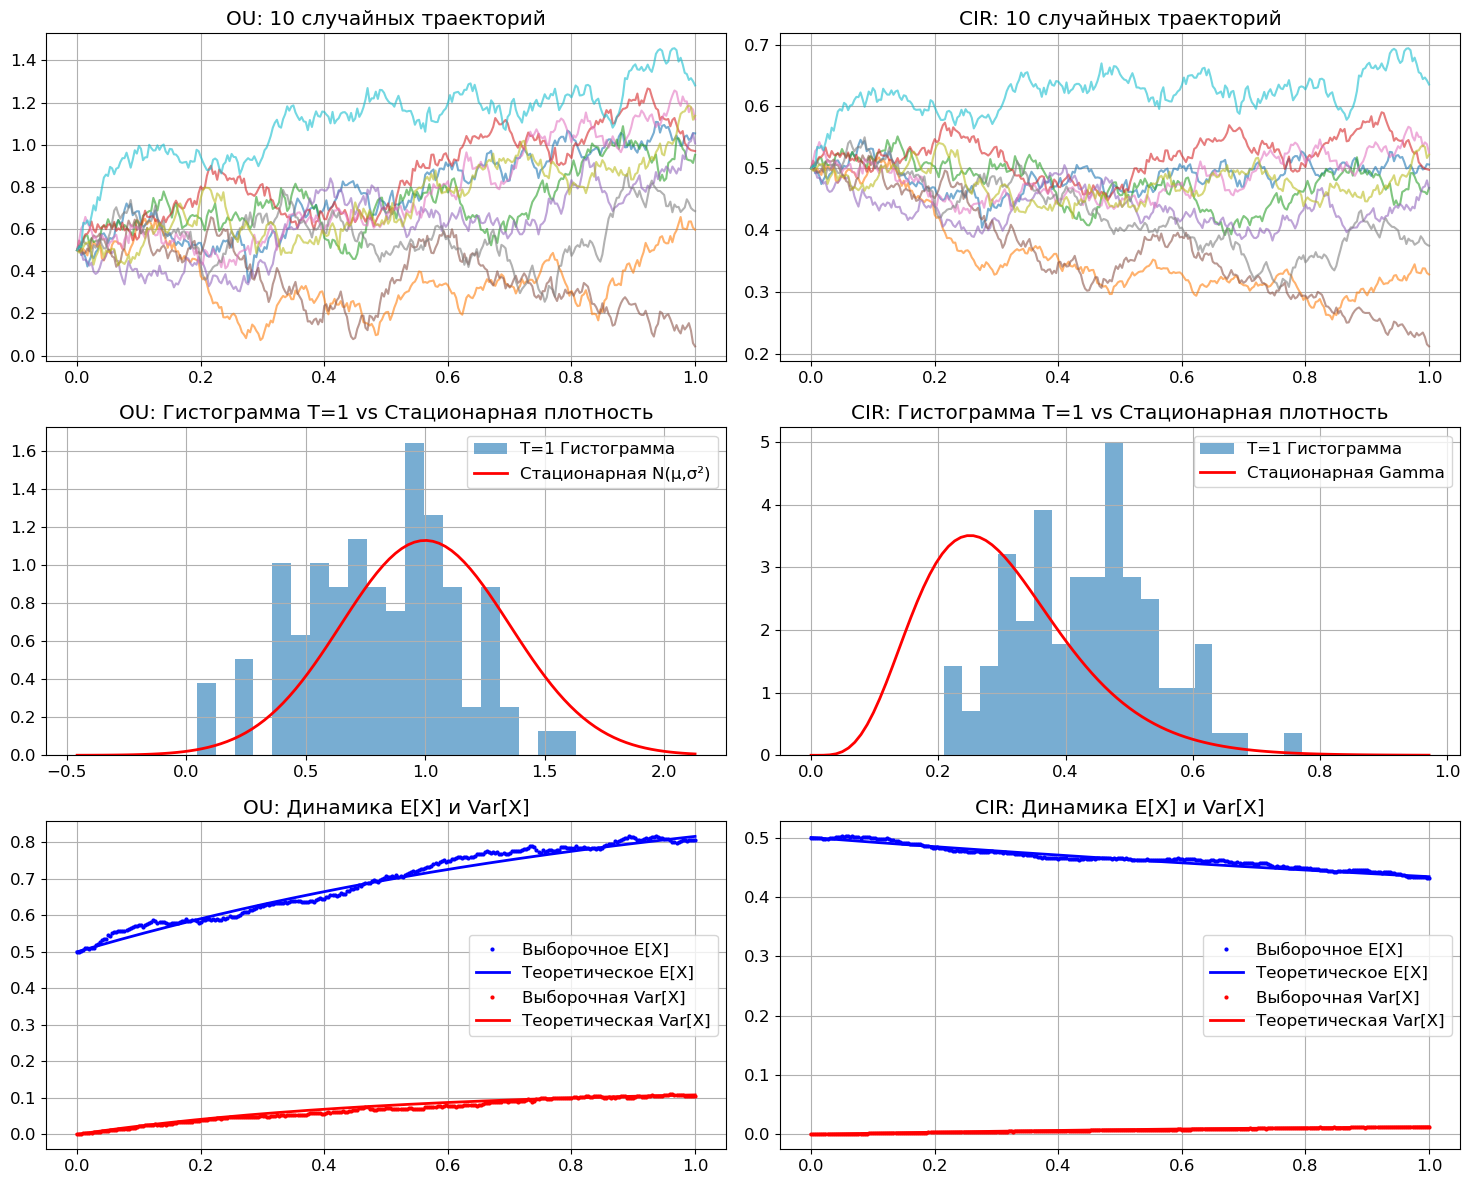

Сравнение в срезах для OU:
t=0.1: Выб. E=0.574 (Теор=0.548) | Выб. Var=0.022 (Теор=0.023)
t=0.5: Выб. E=0.706 (Теор=0.697) | Выб. Var=0.071 (Теор=0.079)
t=1.0: Выб. E=0.807 (Теор=0.816) | Выб. Var=0.105 (Теор=0.108)

Сравнение в срезах для CIR:
t=0.1: Выб. E=0.500 (Теор=0.492) | Выб. Var=0.002 (Теор=0.002)
t=0.5: Выб. E=0.466 (Теор=0.464) | Выб. Var=0.007 (Теор=0.008)
t=1.0: Выб. E=0.432 (Теор=0.434) | Выб. Var=0.012 (Теор=0.013)


In [14]:
fig = plt.figure(figsize=(15, 12))

# 1. Траектории
ax1 = plt.subplot(321)
ax1.plot(t_5, X_OU[:, :10], alpha=0.6)
ax1.set_title("OU: 10 случайных траекторий")

ax2 = plt.subplot(322)
ax2.plot(t_5, X_CIR[:, :10], alpha=0.6)
ax2.set_title("CIR: 10 случайных траекторий")

# 2. Гистограммы в t=T
ax3 = plt.subplot(323)
x_val = np.linspace(X_OU[-1].min()-0.5, X_OU[-1].max()+0.5, 100)
ax3.hist(X_OU[-1], bins=20, density=True, alpha=0.6, label='T=1 Гистограмма')
ax3.plot(x_val, norm.pdf(x_val, ou_stat_mean, np.sqrt(ou_stat_var)), 'r-', lw=2, label='Стационарная N(μ,σ²)')
ax3.set_title("OU: Гистограмма T=1 vs Стационарная плотность")
ax3.legend()

ax4 = plt.subplot(324)
x_val = np.linspace(1e-4, X_CIR[-1].max()+0.2, 100)
ax4.hist(X_CIR[-1], bins=20, density=True, alpha=0.6, label='T=1 Гистограмма')
ax4.plot(x_val, gamma.pdf(x_val, a=cir_shape, scale=cir_scale), 'r-', lw=2, label='Стационарная Gamma')
ax4.set_title("CIR: Гистограмма T=1 vs Стационарная плотность")
ax4.legend()

# 3. Условные моменты
ax5 = plt.subplot(325)
ax5.plot(t_5, X_OU.mean(axis=1), 'bo', markersize=2, label='Выборочное E[X]')
ax5.plot(t_5, E_OU, 'b-', lw=2, label='Теоретическое E[X]')
ax5.plot(t_5, X_OU.var(axis=1), 'ro', markersize=2, label='Выборочная Var[X]')
ax5.plot(t_5, V_OU, 'r-', lw=2, label='Теоретическая Var[X]')
ax5.set_title("OU: Динамика E[X] и Var[X]")
ax5.legend()

ax6 = plt.subplot(326)
ax6.plot(t_5, X_CIR.mean(axis=1), 'bo', markersize=2, label='Выборочное E[X]')
ax6.plot(t_5, E_CIR, 'b-', lw=2, label='Теоретическое E[X]')
ax6.plot(t_5, X_CIR.var(axis=1), 'ro', markersize=2, label='Выборочная Var[X]')
ax6.plot(t_5, V_CIR, 'r-', lw=2, label='Теоретическая Var[X]')
ax6.set_title("CIR: Динамика E[X] и Var[X]")
ax6.legend()

plt.tight_layout()
plt.show()

print("Сравнение в срезах для OU:")
for tt in [0.1, 0.5, 1.0]:
    idx = int(tt / dt_5)
    print(f"t={tt}: Выб. E={X_OU[idx].mean():.3f} (Теор={E_OU[idx]:.3f}) | Выб. Var={X_OU[idx].var():.3f} (Теор={V_OU[idx]:.3f})")

print("\nСравнение в срезах для CIR:")
for tt in [0.1, 0.5, 1.0]:
    idx = int(tt / dt_5)
    print(f"t={tt}: Выб. E={X_CIR[idx].mean():.3f} (Теор={E_CIR[idx]:.3f}) | Выб. Var={X_CIR[idx].var():.3f} (Теор={V_CIR[idx]:.3f})")
